IMPROVED KNN - CSP + RAW FEATURES COMBINED

In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


STEP 1: LOAD ALL AVAILABLE FEATURES

In [ ]:
import os
os.chdir(os.path.join(os.path.dirname(os.path.abspath("__file__")), '..'))

X_train_csp = np.load('X_train_csp.npy')
X_test_csp  = np.load('X_test_csp.npy')
X_train_raw = np.load('X_train.npy')
X_test_raw  = np.load('X_test.npy')
y_train     = np.load('y_train.npy')
y_test      = np.load('y_test.npy')

print("Data loaded!")
print(f"   CSP features  - X_train: {X_train_csp.shape} | X_test: {X_test_csp.shape}")
print(f"   Raw features  - X_train: {X_train_raw.shape} | X_test: {X_test_raw.shape}")
print(f"   Labels        - Train: {np.unique(y_train, return_counts=True)}")
print(f"                   Test:  {np.unique(y_test,  return_counts=True)}")

STEP 2: COMBINE CSP + RAW FEATURES

In [14]:
if X_train_raw.ndim == 3:
    print(f"   Raw features are 3D {X_train_raw.shape} → flattening...")
    X_train_raw = X_train_raw.reshape(X_train_raw.shape[0], -1)
    X_test_raw  = X_test_raw.reshape(X_test_raw.shape[0], -1)
    print(f"   After flatten: {X_train_raw.shape}")

X_train_combined = np.hstack([X_train_csp, X_train_raw])
X_test_combined  = np.hstack([X_test_csp,  X_test_raw])
print(f"\n✅ Combined features: {X_train_combined.shape}")


   Raw features are 3D (3913, 9, 513) → flattening...
   After flatten: (3913, 4617)

✅ Combined features: (3913, 4623)


STEP 3: SCALE FEATURES

In [15]:

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_combined)
X_test_s  = scaler.transform(X_test_combined)
print("✅ Features scaled!")


✅ Features scaled!


STEP 4: TEST 3 APPROACHES AND COMPARE


In [16]:


results = {}

# --- Approach A: CSP only ---
print("\n🔍 Approach A: CSP features only...")
scaler_a = StandardScaler()
Xtr_a = scaler_a.fit_transform(X_train_csp)
Xte_a = scaler_a.transform(X_test_csp)

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}
gs_a = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gs_a.fit(Xtr_a, y_train)
y_pred_a = gs_a.best_estimator_.predict(Xte_a)
results['CSP Only'] = accuracy_score(y_test, y_pred_a)
print(f"   Best params: {gs_a.best_params_}")
print(f"   Accuracy: {results['CSP Only']:.4f}")

# --- Approach B: Raw features only ---
print("\n🔍 Approach B: Raw features only...")
scaler_b = StandardScaler()
Xtr_b = scaler_b.fit_transform(X_train_raw)
Xte_b = scaler_b.transform(X_test_raw)

gs_b = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gs_b.fit(Xtr_b, y_train)
y_pred_b = gs_b.best_estimator_.predict(Xte_b)
results['Raw Only'] = accuracy_score(y_test, y_pred_b)
print(f"   Best params: {gs_b.best_params_}")
print(f"   Accuracy: {results['Raw Only']:.4f}")

# --- Approach C: Combined features ---
print("\n🔍 Approach C: Combined CSP + Raw features...")
gs_c = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gs_c.fit(X_train_s, y_train)
y_pred_c = gs_c.best_estimator_.predict(X_test_s)
results['Combined'] = accuracy_score(y_test, y_pred_c)
print(f"   Best params: {gs_c.best_params_}")
print(f"   Accuracy: {results['Combined']:.4f}")

# --- Approach D: Combined + PCA dimensionality reduction ---
print("\n🔍 Approach D: Combined + PCA...")
pca = PCA(n_components=0.95)  # keep 95% variance
Xtr_pca = pca.fit_transform(X_train_s)
Xte_pca = pca.transform(X_test_s)
print(f"   PCA reduced to {Xtr_pca.shape[1]} components")

gs_d = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gs_d.fit(Xtr_pca, y_train)
y_pred_d = gs_d.best_estimator_.predict(Xte_pca)
results['Combined + PCA'] = accuracy_score(y_test, y_pred_d)
print(f"   Best params: {gs_d.best_params_}")
print(f"   Accuracy: {results['Combined + PCA']:.4f}")


🔍 Approach A: CSP features only...
   Best params: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}
   Accuracy: 0.5838

🔍 Approach B: Raw features only...
   Best params: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
   Accuracy: 0.5036

🔍 Approach C: Combined CSP + Raw features...
   Best params: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}
   Accuracy: 0.5299

🔍 Approach D: Combined + PCA...
   PCA reduced to 725 components
   Best params: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
   Accuracy: 0.5310


In [17]:
print("X_train_raw shape:", X_train_raw.shape)
print("X_train_csp shape:", X_train_csp.shape)
print("Sample raw values:", X_train_raw[0])

X_train_raw shape: (3913, 4617)
X_train_csp shape: (3913, 6)
Sample raw values: [ 1.84241696e-08  5.79841084e-07  1.41423042e-06 ... -1.08226839e-06
 -6.18645169e-06 -8.71258946e-06]


STEP 5: BEST MODEL - DETAILED REPORT

In [18]:
best_approach = max(results, key=results.get)
best_acc      = results[best_approach]

print(f"\n{'='*50}")
print(f"  🏆 Best Approach: {best_approach}")
print(f"  🏆 Best Accuracy: {best_acc:.4f} ({best_acc:.2%})")
print(f"{'='*50}")

# Pick best predictions for confusion matrix
best_preds = {'CSP Only': y_pred_a, 'Raw Only': y_pred_b,
              'Combined': y_pred_c, 'Combined + PCA': y_pred_d}
y_pred_best = best_preds[best_approach]

print("\nClassification Report (Best Model):")
print(classification_report(y_test, y_pred_best, 
      target_names=['Left (0)', 'Right (1)'], zero_division=0))


  🏆 Best Approach: CSP Only
  🏆 Best Accuracy: 0.5838 (58.38%)

Classification Report (Best Model):
              precision    recall  f1-score   support

    Left (0)       0.58      0.65      0.61       497
   Right (1)       0.59      0.52      0.55       488

    accuracy                           0.58       985
   macro avg       0.58      0.58      0.58       985
weighted avg       0.58      0.58      0.58       985



STEP 6: CONFUSION MATRIX

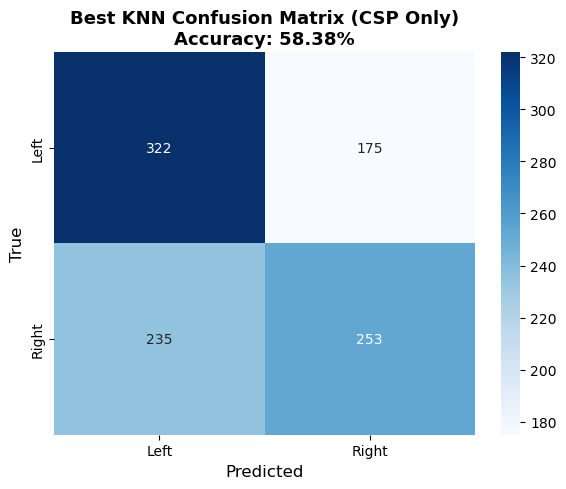

In [19]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Left', 'Right'],
            yticklabels=['Left', 'Right'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title(f'Best KNN Confusion Matrix ({best_approach})\nAccuracy: {best_acc:.2%}',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

STEP 7: ACCURACY COMPARISON CHART


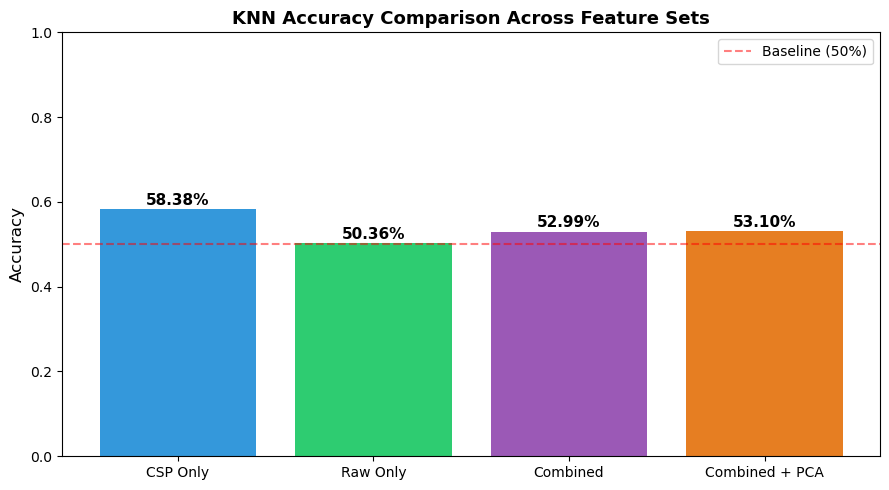


✅ Done! Check the comparison chart to see which approach works best.


In [20]:
plt.figure(figsize=(9, 5))
bars = plt.bar(results.keys(), results.values(),
               color=['#3498db', '#2ecc71', '#9b59b6', '#e67e22'])
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN Accuracy Comparison Across Feature Sets', fontsize=13, fontweight='bold')
plt.ylim(0, 1.0)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Baseline (50%)')

for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.2%}', ha='center', fontsize=11, fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("\n✅ Done! Check the comparison chart to see which approach works best.")
